# Brightline `bookings.csv` — Data Exploration

Goal: understand this dataset before building the UI, and find the things that would make a naive answer wrong, as the brief asks.

Questions covered:
1. Whether data that should be unique has duplicates, e.g. duplicate `booking_id`s
2. Basic numbers: how many desks per floor, how many teams, and how many people per team
3. Checks on `booking_date`, `booked_at`, `checked_in_at`
- How many rows have `booked_at` later than `checked_in_at`
- Whether `booking_date` and `booked_at` are both present on every row; if not, the check-in system may have a problem
- Whether `booking_date` and `checked_in_at` are ever inconsistent
- `booking_date` and `checked_in_at` only fall on Monday–Friday; there is no weekend data
4. Cross-classification into four states: booked but not checked in / checked in but not booked / booked and checked in normally / booked and checked in but with a timestamp anomaly
5. Missing check-ins (no-shows) — distribution by day of week / floor / team
6. Per-floor summary

In [1]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('bookings.csv', parse_dates=['booking_date', 'booked_at', 'checked_in_at'])
print(df.shape)
df.head()

(17929, 8)


,booking_id,booking_date,desk_id,floor,employee_id,team,booked_at,checked_in_at
0,B000001,2026-06-01,D2086,2,E0002,Finance,2026-05-31 11:21:00,2026-06-01 08:50:00
1,B000002,2026-06-01,D3016,3,E0005,Engineering,2026-05-31 17:21:00,2026-06-01 07:33:00
2,B000003,2026-06-01,D3048,3,E0010,People,2026-06-01 15:27:00,2026-06-01 09:59:00
3,B000004,2026-06-01,D3075,3,E0012,Engineering,2026-05-31 18:31:00,NaT
4,B000005,2026-06-01,D3087,3,E0014,People,2026-05-30 17:08:00,2026-06-01 09:13:00


## 0. Basic health check
First look at data types, date range, missing values, and structural issues such as duplicates / double bookings.

In [2]:
print('dtypes:')
print(df.dtypes)
print()
print('date range:', df['booking_date'].min(), '->', df['booking_date'].max())
print('distinct booking days:', df['booking_date'].nunique())
print()
print('missing values per column:')
print(df.isna().sum())
print()
print('duplicate booking_id:', df['booking_id'].duplicated().sum())
dup_desk_day = df.duplicated(subset=['desk_id', 'booking_date']).sum()
print('same desk booked twice same day:', dup_desk_day)
print()
print('booking_date day-of-week coverage (0=Mon):', sorted(df['booking_date'].dt.weekday.unique()))
print('checked_in_at day-of-week coverage (0=Mon):', sorted(df['checked_in_at'].dt.weekday.unique()))

dtypes:
booking_id                  str
booking_date     datetime64[us]
desk_id                     str
floor                     int64
employee_id                 str
team                        str
booked_at        datetime64[us]
checked_in_at    datetime64[us]
dtype: object

date range: 2026-06-01 00:00:00 -> 2026-08-31 00:00:00
distinct booking days: 66

missing values per column:
booking_id          0
booking_date        0
desk_id             0
floor               0
employee_id         0
team                0
booked_at           0
checked_in_at    6228
dtype: int64

duplicate booking_id: 0
same desk booked twice same day: 0

booking_date day-of-week coverage (0=Mon): [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
checked_in_at day-of-week coverage (0=Mon): [np.float64(0.0), np.float64(nan), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


**Conclusion**: no duplicate `booking_id`, no desk booked twice on the same day, and records only exist for weekdays (Monday–Friday), with no weekend data. `checked_in_at` has many missing values (expected — people who don't show up don't check in); the other columns are complete.

### 0.1 Does any employee book more than one desk on the same day?
Each `(employee_id, booking_date)` pair should be unique. If it isn't, the same person holds several desks on one day and per-person counts would double count.

In [8]:
emp_day_counts = df.groupby(['employee_id', 'booking_date']).size()
multi_desk = emp_day_counts[emp_day_counts > 1]
print('(employee_id, booking_date) pairs with >1 booking:', len(multi_desk))
print('rows involved:', multi_desk.sum())
if len(multi_desk):
    print(multi_desk.value_counts().sort_index())
    display(df.set_index(['employee_id', 'booking_date']).loc[multi_desk.index].reset_index().head(15))

(employee_id, booking_date) pairs with >1 booking: 0
rows involved: 0


### 0.2 Are `booking_date` and `booked_at` both present on every row?
`booking_date` is the day the desk was booked for; `booked_at` is when the booking was made. Both should always be present, and `booked_at` should not be later than the `booking_date` day; otherwise the booking / check-in system's records may be faulty.

In [9]:
has_bd = df['booking_date'].notna()
has_ba = df['booked_at'].notna()
print('both present      :', (has_bd & has_ba).sum())
print('booking_date only :', (has_bd & ~has_ba).sum())
print('booked_at only    :', (~has_bd & has_ba).sum())
print('neither           :', (~has_bd & ~has_ba).sum())
print()

# how many days in advance was the desk booked? (negative = booked after the booking day, impossible)
lead_days = (df['booking_date'] - df['booked_at'].dt.normalize()).dt.days
print('lead time (booking_date - booked_at date, days):')
print(lead_days.value_counts().sort_index())
print('booked_at after booking_date:', (lead_days < 0).sum())

both present      : 17929
booking_date only : 0
booked_at only    : 0
neither           : 0

lead time (booking_date - booked_at date, days):
0    6175
1    5453
2    2710
3    2196
7    1395
Name: count, dtype: int64
booked_at after booking_date: 0


### 0.3 Is `checked_in_at` consistent with `booking_date`?
For rows with a check-in, the check-in date should equal `booking_date` (a check-in must happen on the day that was booked).

In [10]:
checked = df[df['checked_in_at'].notna()]
checkin_day_diff = (checked['checked_in_at'].dt.normalize() - checked['booking_date']).dt.days
print('checked-in rows:', len(checked))
print('checkin date - booking_date (days):')
print(checkin_day_diff.value_counts().sort_index())
print('mismatched rows:', (checkin_day_diff != 0).sum())
print()
print('check-in hour distribution:')
print(checked['checked_in_at'].dt.hour.value_counts().sort_index())

checked.loc[checkin_day_diff != 0, ['booking_id', 'booking_date', 'booked_at', 'checked_in_at']].head(15)

checked-in rows: 11701
checkin date - booking_date (days):
0    11701
Name: count, dtype: int64
mismatched rows: 0

check-in hour distribution:
checked_in_at
6       84
7     1389
8     5506
9     4009
10     693
11      20
Name: count, dtype: int64


,booking_id,booking_date,booked_at,checked_in_at


**Conclusion**:
- `(employee_id, booking_date)` is fully unique: no employee booked more than one desk on the same day.
- `booking_date` and `booked_at` are both present on every row; `booked_at` is always on or before the `booking_date` day (0/1/2/3/7 days in advance), with no bookings made after the booked day.
- For every checked-in row, the check-in date equals `booking_date`, and check-in times are concentrated between 6 and 11 am, so there is no inconsistency at the date level.
- There is a problem at the time-of-day level, though: many same-day bookings have `booked_at` later than `checked_in_at`; see Section 3.

## 1. How many desks are on each floor?
Group by `floor` and count unique `desk_id`s.

In [4]:
desks_per_floor = df.groupby('floor')['desk_id'].nunique().sort_index()
print(desks_per_floor)
print('total unique desks across all floors:', df['desk_id'].nunique())


floor
1     90
2    110
3    110
4     90
Name: desk_id, dtype: int64
total unique desks across all floors: 400


## 2. How many teams are there, and how many people are on each team?
Note: count people by unique `employee_id`, not by rows (one person has many booking records).

In [5]:
print('number of teams:', df['team'].nunique())

people_per_team = df.groupby('team')['employee_id'].nunique().sort_values(ascending=False)
print(people_per_team)
print('total unique employees:', df['employee_id'].nunique())

# sanity check: does any employee_id appear under more than one team?
emp_team_counts = df.groupby('employee_id')['team'].nunique()
print()
print('employees associated with >1 team (data quality check):', (emp_team_counts > 1).sum())


number of teams: 8
team
Engineering        162
Sales              121
Client Services    100
Marketing           66
Finance             48
Data                44
People              35
Legal               24
Name: employee_id, dtype: int64
total unique employees: 600

employees associated with >1 team (data quality check): 0


## 3. How many rows have `booked_at` later than `checked_in_at`?
Normally a person books first (`booked_at`) and checks in on arrival later (`checked_in_at`). If `booked_at > checked_in_at`, the check-in happened before the booking was made — logically impossible, so it is a data anomaly (possibly back-filled entries, clock skew, or a system issue). Only rows with a non-null `checked_in_at` are counted.

In [6]:
has_checkin = df['checked_in_at'].notna()
booked_after_checkin = has_checkin & (df['booked_at'] > df['checked_in_at'])

n = booked_after_checkin.sum()
pct_of_checked_in = n / has_checkin.sum() * 100
pct_of_all = n / len(df) * 100
print(f'rows where booked_at > checked_in_at: {n}')
print(f'  = {pct_of_checked_in:.2f}% of all checked-in rows')
print(f'  = {pct_of_all:.2f}% of all rows')

df.loc[booked_after_checkin, ['booking_id','booking_date','desk_id','floor','employee_id','team','booked_at','checked_in_at']].head(15)

rows where booked_at > checked_in_at: 3698
  = 31.60% of all checked-in rows
  = 20.63% of all rows


,booking_id,booking_date,desk_id,floor,employee_id,team,booked_at,checked_in_at
2,B000003,2026-06-01,D3048,3,E0010,People,2026-06-01 15:27:00,2026-06-01 09:59:00
6,B000007,2026-06-01,D1010,1,E0018,Marketing,2026-06-01 15:15:00,2026-06-01 10:01:00
7,B000008,2026-06-01,D4049,4,E0021,Marketing,2026-06-01 09:00:00,2026-06-01 08:58:00
9,B000010,2026-06-01,D2090,2,E0024,People,2026-06-01 15:08:00,2026-06-01 09:06:00
12,B000013,2026-06-01,D1005,1,E0028,Client Services,2026-06-01 18:20:00,2026-06-01 08:43:00
22,B000023,2026-06-01,D1011,1,E0063,Client Services,2026-06-01 17:02:00,2026-06-01 09:17:00
23,B000024,2026-06-01,D4059,4,E0066,Client Services,2026-06-01 17:07:00,2026-06-01 09:38:00
27,B000028,2026-06-01,D3028,3,E0073,Marketing,2026-06-01 08:07:00,2026-06-01 07:03:00
33,B000034,2026-06-01,D2091,2,E0088,Engineering,2026-06-01 18:19:00,2026-06-01 08:16:00
36,B000037,2026-06-01,D4048,4,E0093,Client Services,2026-06-01 18:15:00,2026-06-01 08:54:00


In [7]:
# how far off is the gap, and is it concentrated anywhere (floor / team / specific dates)?
gap = (df.loc[booked_after_checkin, 'booked_at'] - df.loc[booked_after_checkin, 'checked_in_at'])
print('gap stats (booked_at - checked_in_at) for the anomalous rows:')
print(gap.describe())
print()
print('by floor:')
print(df.loc[booked_after_checkin, 'floor'].value_counts().sort_index())
print()
print('by team:')
print(df.loc[booked_after_checkin, 'team'].value_counts())
print()
print('by booking_date (top 10):')
print(df.loc[booked_after_checkin, 'booking_date'].value_counts().sort_index().tail(10))

gap stats (booked_at - checked_in_at) for the anomalous rows:
count                      3698
mean     0 days 05:07:32.076798
std      0 days 02:57:41.892455
min             0 days 00:01:00
25%             0 days 02:36:00
50%             0 days 05:01:00
75%             0 days 07:38:00
max             0 days 11:53:00
dtype: object

by floor:
floor
1     831
2    1020
3    1001
4     846
Name: count, dtype: int64

by team:
team
Sales              945
Client Services    910
Engineering        614
Marketing          365
People             328
Finance            282
Data               144
Legal              110
Name: count, dtype: int64

by booking_date (top 10):
booking_date
2026-08-18    88
2026-08-19    80
2026-08-20    59
2026-08-21    18
2026-08-24    65
2026-08-25    61
2026-08-26    80
2026-08-27    48
2026-08-28    20
2026-08-31    55
Name: count, dtype: int64


In [7]:
# is the booked_at > checked_in_at anomaly random noise, or a specific pattern?
# check whether it's concentrated among bookings made on the SAME day as the visit (walk-ins)
# vs bookings made in advance (the day before or earlier)
df['booked_same_day'] = df['booked_at'].dt.date == df['booking_date'].dt.date

print('anomalous rows (booked_at > checked_in_at) -- booked same day as the visit?')
print(df.loc[booked_after_checkin, 'booked_same_day'].value_counts())
print()

normal_checkin = has_checkin & ~booked_after_checkin
print('normal checked-in rows -- booked same day as the visit?')
print(df.loc[normal_checkin, 'booked_same_day'].value_counts())
print()

print('no-show rows -- booked same day as the visit?')
print(df.loc[~has_checkin, 'booked_same_day'].value_counts())

anomalous rows (booked_at > checked_in_at) -- booked same day as the visit?
booked_same_day
True    3698
Name: count, dtype: int64

normal checked-in rows -- booked same day as the visit?
booked_same_day
False    7692
True      311
Name: count, dtype: int64

no-show rows -- booked same day as the visit?
booked_same_day
False    4062
True     2166
Name: count, dtype: int64


### This anomaly is not random noise but an explainable pattern

**All 3,698 rows with `booked_at > checked_in_at` are 100% same-day bookings (`booked_at` falls on the same day as `booking_date`).** Conversely, among normally checked-in rows only 309/8,001 (about 4%) are same-day bookings; the rest were booked a day or more in advance.

In other words: **this is not data corruption but a systematic trait of same-day / walk-in bookings** — these people most likely went to a desk first and checked in and booked on the spot (or almost simultaneously) in the app, so by the time the backend recorded the `booked_at` timestamp it was already later than `checked_in_at` (most likely the system's timestamping for same-day bookings lags, rather than unusual user behavior).

**Implication for UI design**: we cannot simply use "is `booked_at` earlier than `checked_in_at`" to decide whether a record is "dirty" — for same-day bookings, the reversed order is normal. The only field that should decide whether a desk was used, from start to finish, is whether `checked_in_at` is null

## 4. Distribution of no-shows: day of week / floor / team
Look at the overall missing rate first, then drill down by day — this surfaces an anomaly that must be flagged in the UI.

In [8]:
df['is_no_show'] = df['checked_in_at'].isna()
overall_rate = df['is_no_show'].mean() * 100
print(f'overall no-show rate: {overall_rate:.1f}%  ({df["is_no_show"].sum()} of {len(df)} desk-days)')

overall no-show rate: 34.7%  (6228 of 17929 desk-days)


no-show rate (%) by day of week:
     mean   sum  count
dow                   
Mon  36.9  1219   3301
Tue  32.4  1496   4618
Wed  32.9  1570   4768
Thu  34.8  1259   3621
Fri  42.2   684   1621


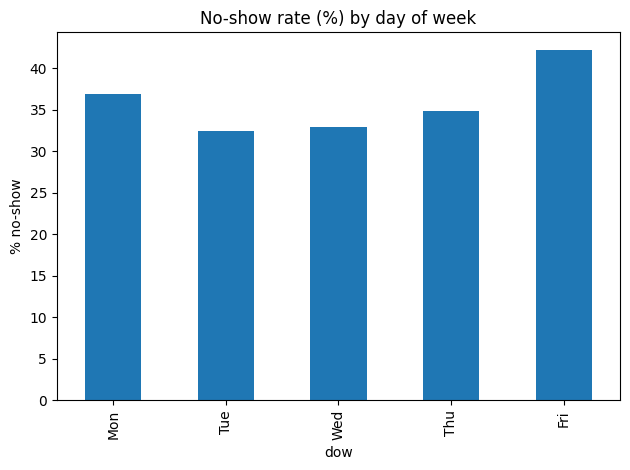

In [9]:
# by day of week
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['dow'] = df['booking_date'].dt.weekday.map(lambda i: dow_names[i])

by_dow = df.groupby('dow')['is_no_show'].agg(['mean','sum','count']).reindex(dow_names[:5])
by_dow['mean'] = (by_dow['mean']*100).round(1)
print('no-show rate (%) by day of week:')
print(by_dow)

by_dow['mean'].plot(kind='bar', title='No-show rate (%) by day of week', ylabel='% no-show')
plt.tight_layout(); plt.show()

no-show rate (%) by floor:
       mean   sum  count
floor                   
1      35.1  1418   4045
2      35.4  1728   4887
3      33.9  1672   4927
4      34.6  1410   4070


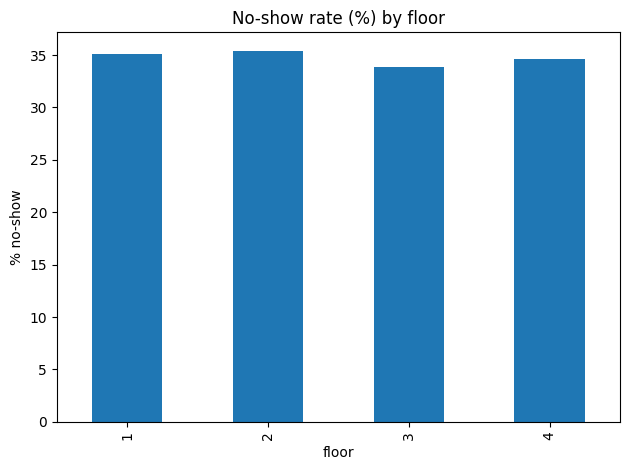

In [10]:
# by floor
by_floor = df.groupby('floor')['is_no_show'].agg(['mean','sum','count']).sort_index()
by_floor['mean'] = (by_floor['mean']*100).round(1)
print('no-show rate (%) by floor:')
print(by_floor)

by_floor['mean'].plot(kind='bar', title='No-show rate (%) by floor', ylabel='% no-show')
plt.tight_layout(); plt.show()

no-show rate (%) by team:
                 mean   sum  count
team                              
Data             50.6   451    892
Engineering      46.8  1673   3573
Marketing        39.0   725   1859
Finance          35.2   541   1537
Legal            34.9   208    596
Sales            29.8  1255   4207
Client Services  27.3  1059   3878
People           22.8   316   1387


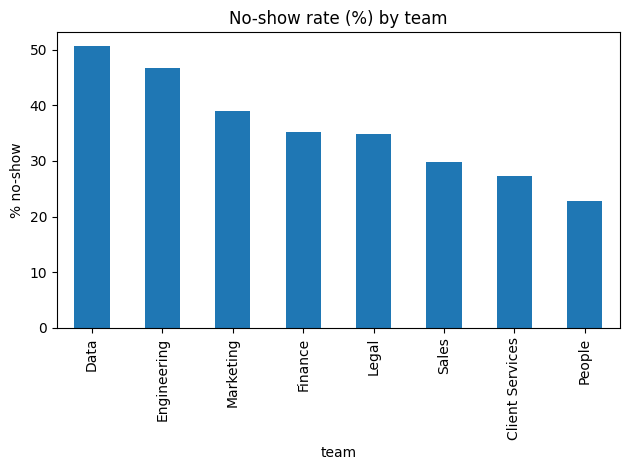

In [11]:
# by team (not by named employee, per the brief)
by_team = df.groupby('team')['is_no_show'].agg(['mean','sum','count']).sort_values('mean', ascending=False)
by_team['mean'] = (by_team['mean']*100).round(1)
print('no-show rate (%) by team:')
print(by_team)

by_team['mean'].plot(kind='bar', title='No-show rate (%) by team', ylabel='% no-show')
plt.tight_layout(); plt.show()

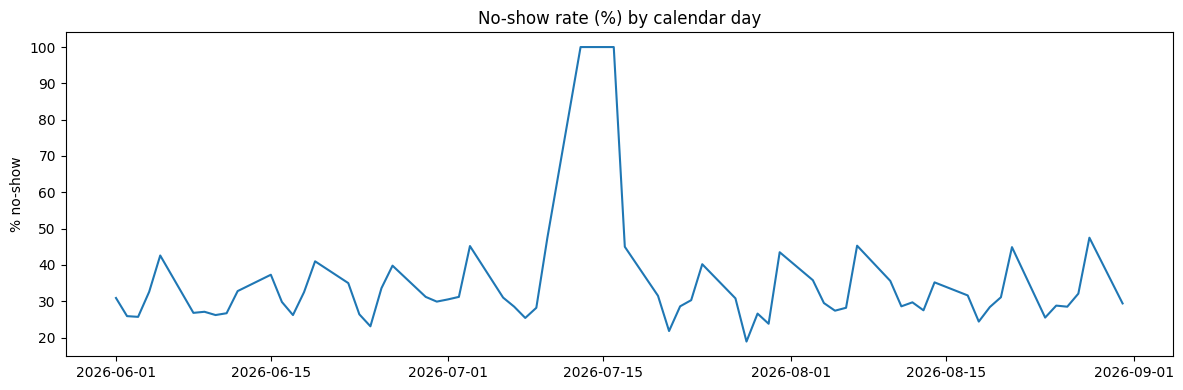

days where the no-show rate is suspiciously extreme (>=80% or <=5%):
               mean  sum  count
booking_date                   
2026-07-13    100.0  250    250
2026-07-14    100.0  363    363
2026-07-15    100.0  376    376
2026-07-16    100.0  255    255


In [12]:
# by calendar day -- this is where the real problem shows up
by_day = df.groupby('booking_date')['is_no_show'].agg(['mean','sum','count'])
by_day['mean'] = (by_day['mean']*100).round(1)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(by_day.index, by_day['mean'])
ax.set_title('No-show rate (%) by calendar day')
ax.set_ylabel('% no-show')
plt.tight_layout(); plt.show()

print('days where the no-show rate is suspiciously extreme (>=80% or <=5%):')
print(by_day[(by_day['mean'] >= 80) | (by_day['mean'] <= 5)])

### Issue found: 0% check-in rate from 2026-07-13 to 2026-07-16

On these four weekdays (Monday–Thursday), **100% of bookings have no check-in record**

In [13]:
# confirm the exact broken window and its blast radius
broken_dates = by_day[by_day['mean'] >= 95].index
print('broken dates:', list(broken_dates.date))

broken_mask = df['booking_date'].isin(broken_dates)
print('rows affected:', broken_mask.sum(), f'({broken_mask.mean()*100:.1f}% of all rows)')
print('affects floors:', sorted(df.loc[broken_mask, 'floor'].unique()))
print('affects teams:', sorted(df.loc[broken_mask, 'team'].unique()))

# what the July no-show rate looks like with vs without the broken window
july = df[df['booking_date'].dt.month == 7]
july_incl = july['is_no_show'].mean() * 100
july_excl = july.loc[~july['booking_date'].isin(broken_dates), 'is_no_show'].mean() * 100
print()
print(f'July no-show rate including broken window: {july_incl:.1f}%')
print(f'July no-show rate excluding broken window:  {july_excl:.1f}%')

broken dates: [datetime.date(2026, 7, 13), datetime.date(2026, 7, 14), datetime.date(2026, 7, 15), datetime.date(2026, 7, 16)]
rows affected: 1244 (6.9% of all rows)
affects floors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
affects teams: ['Client Services', 'Data', 'Engineering', 'Finance', 'Legal', 'Marketing', 'People', 'Sales']

July no-show rate including broken window: 43.6%
July no-show rate excluding broken window:  29.4%


## 5. Cross-classification into four states

The data is "one row = one booking", so strictly speaking every row is by nature "booked" — there are no check-in records that exist independently of a booking record. Therefore:

- **Booked but not checked in (no-show)**: `checked_in_at` is null — this state really exists.
- **Checked in but not booked**: **structurally impossible** under the current schema (there are no check-in records outside a booking row). Below we still verify that it is indeed 0, as a data-integrity check.
- **Booked and checked in normally**: `checked_in_at` is not null and `booked_at < checked_in_at` (booked first, arrived later — logically consistent).
- **Booked and checked in, but with a timestamp anomaly**: `checked_in_at` is not null but `booked_at >= checked_in_at` (check-in earlier than or equal to the booking time — logically problematic; this is the anomaly found in Section 3).

                                                    count  pct_%
status                                                          
booked_and_checked_in (normal)                       8001  44.63
booked_no_checkin (no-show)                          6228  34.74
booked_and_checked_in (anomaly: booked_at >= ch...   3700  20.64

"checked in but not booked" -- not representable in this schema (every row is a booking). Count: 0 by construction.


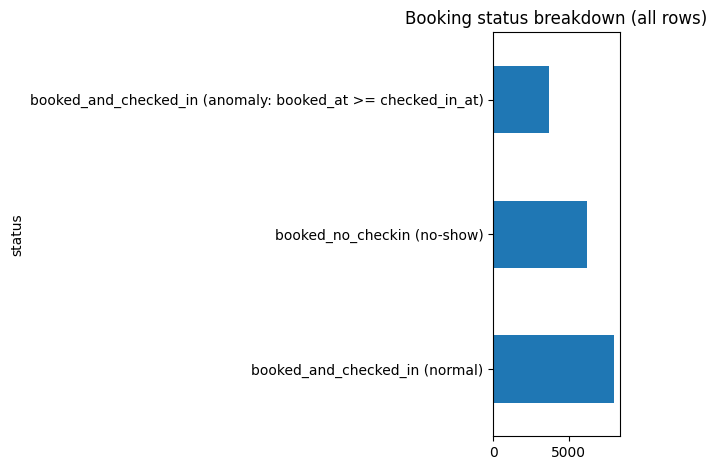

In [14]:
def classify(row):
    if pd.isna(row['checked_in_at']):
        return 'booked_no_checkin (no-show)'
    elif row['booked_at'] < row['checked_in_at']:
        return 'booked_and_checked_in (normal)'
    else:
        return 'booked_and_checked_in (anomaly: booked_at >= checked_in_at)'

df['status'] = df.apply(classify, axis=1)

status_counts = df['status'].value_counts()
status_pct = (df['status'].value_counts(normalize=True) * 100).round(2)
summary = pd.DataFrame({'count': status_counts, 'pct_%': status_pct})
print(summary)

print()
print('"checked in but not booked" -- not representable in this schema (every row is a booking). Count: 0 by construction.')

status_counts.plot(kind='barh', title='Booking status breakdown (all rows)')
plt.tight_layout(); plt.show()

### True no-show distribution by team (excluding the broken 7/13–7/16 data window)
This is the core of the brief's second question: where is the waste concentrated?

(excluding the broken 2026-07-13 to 2026-07-16 window)
                 no_show_rate_%  no_show_desk_days  total_bookings
team                                                              
Data                       46.5                383             824
Engineering                42.7               1418            3318
Marketing                  34.5                598            1732
Legal                      30.7                172             560
Finance                    30.3                433            1429
Sales                      24.7                966            3918
Client Services            22.0                797            3616
People                     16.8                217            1288


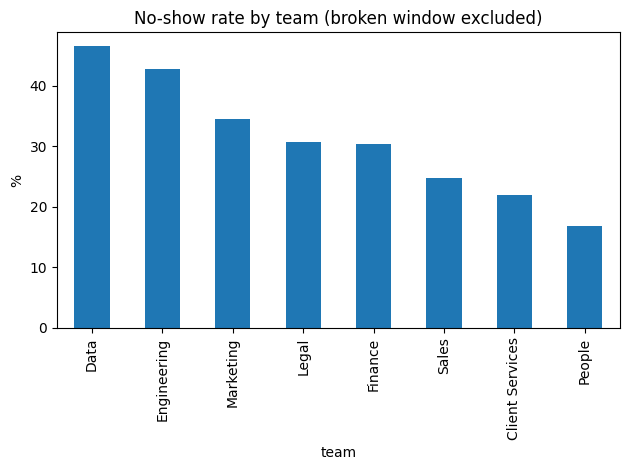

In [15]:
clean = df[~df['booking_date'].isin(broken_dates)].copy()

no_show_by_team_clean = clean.groupby('team')['is_no_show'].agg(['mean','sum','count']).sort_values('mean', ascending=False)
no_show_by_team_clean['mean'] = (no_show_by_team_clean['mean']*100).round(1)
no_show_by_team_clean.columns = ['no_show_rate_%', 'no_show_desk_days', 'total_bookings']
print('(excluding the broken 2026-07-13 to 2026-07-16 window)')
print(no_show_by_team_clean)

no_show_by_team_clean['no_show_rate_%'].plot(kind='bar', title='No-show rate by team (broken window excluded)', ylabel='%')
plt.tight_layout(); plt.show()

## 6. Overall picture per floor
Summarize desk count, bookings, true utilization, and no-shows in one table (with the broken window excluded, to get trustworthy numbers).

In [16]:
n_weekdays_clean = clean['booking_date'].nunique()

floor_summary = clean.groupby('floor').agg(
    desks=('desk_id', 'nunique'),
    total_bookings=('booking_id', 'count'),
    used_desk_days=('is_no_show', lambda s: (~s).sum()),
    no_show_desk_days=('is_no_show', 'sum'),
).sort_index()

floor_summary['no_show_rate_%'] = (floor_summary['no_show_desk_days'] / floor_summary['total_bookings'] * 100).round(1)
# "how full, really": used desk-days vs. desk-days available (desks * weekdays in clean range)
floor_summary['available_desk_days'] = floor_summary['desks'] * n_weekdays_clean
floor_summary['true_utilization_%'] = (floor_summary['used_desk_days'] / floor_summary['available_desk_days'] * 100).round(1)

print(f'(clean weekdays used as denominator: {n_weekdays_clean}, broken window excluded)')
floor_summary

(clean weekdays used as denominator: 62, broken window excluded)


,desks,total_bookings,used_desk_days,no_show_desk_days,no_show_rate_%,available_desk_days,true_utilization_%
floor,,,,,,,
1,90,3761,2627,1134,30.2,5580,47.1
2,110,4544,3159,1385,30.5,6820,46.3
3,110,4590,3255,1335,29.1,6820,47.7
4,90,3790,2660,1130,29.8,5580,47.7


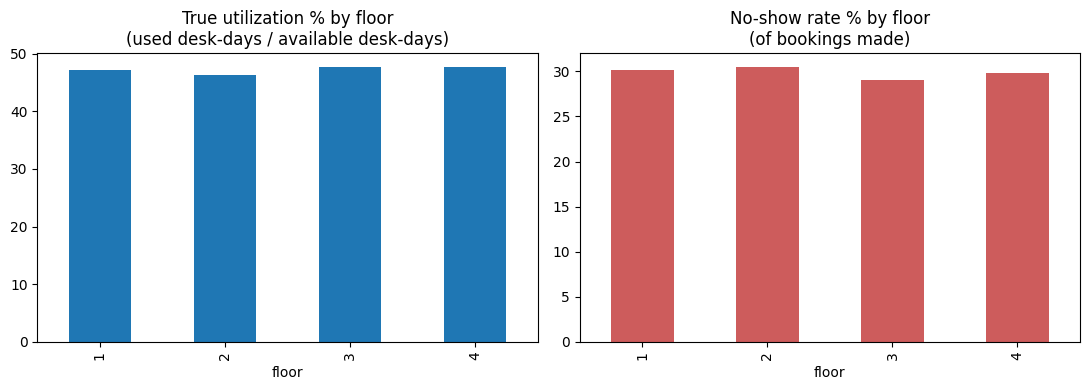

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
floor_summary['true_utilization_%'].plot(kind='bar', ax=axes[0], title='True utilization % by floor\n(used desk-days / available desk-days)')
floor_summary['no_show_rate_%'].plot(kind='bar', ax=axes[1], title='No-show rate % by floor\n(of bookings made)', color='indianred')
plt.tight_layout(); plt.show()

## Summary (to guide the UI design)

Conclusions in the order of the questions listed at the top.

**1. Duplicates in data that should be unique**
- No duplicate `booking_id`, no desk booked twice on the same day, and no employee booked more than one desk on the same day (`(employee_id, booking_date)` is unique).
- No employee appears under more than one team.

**2. Basic numbers**
- 400 desks across 4 floors: floor 1 = 90, floor 2 = 110, floor 3 = 110, floor 4 = 90.
- 8 teams and 600 employees: Engineering 162, Sales 121, Client Services 100, Marketing 66, Finance 48, Data 44, People 35, Legal 24.

**3. Checks on `booking_date`, `booked_at`, `checked_in_at`**
- **`booked_at` later than `checked_in_at`**: 3,698 rows (31.6% of checked-in rows, 20.6% of all rows). This is not minor noise. Every one of them is a same-day booking, and the gap ranges from 1 minute to ~11.9 hours (median ~5 hours). It is spread across all floors, teams and dates. These people did show up, so they still count as "used"; the `booked_at` timestamp of same-day bookings should not be trusted (e.g. for booking lead-time analysis).
- **`booking_date` and `booked_at` presence**: both present on all 17,929 rows, so there is no sign of missing booking records. `booked_at` is always 0, 1, 2, 3 or 7 days before `booking_date`, never after it.
- **`booking_date` vs `checked_in_at`**: all 11,701 check-ins fall on the `booking_date` day, between 6 and 11 am. No date mismatches.
- **Weekdays only**: data covers 2026-06-01 to 2026-08-31 (66 distinct days), Monday–Friday only, with no weekend bookings or check-ins.

**4. Four-state cross-classification**
- Booked and checked in normally: 8,001 (44.6%)
- Booked but not checked in (no-show): 6,228 (34.7%)
- Booked and checked in with a timestamp anomaly (`booked_at >= checked_in_at`): 3,700 (20.6%; 3,698 strictly later plus 2 with identical timestamps)
- Checked in but not booked: 0 — not representable in this schema.

**5. No-show distribution**
- Overall no-show rate: 34.7% (6,228 of 17,929 desk-days).
- **The real problem: 2026-07-13 to 2026-07-16 have a 0% check-in rate.** 1,244 rows (6.9% of all rows) across every floor and team. This is a system failure, not a real absence of people. Including it pushes the July no-show rate from 29.4% to 43.6%. **The UI must flag this window explicitly and exclude it from (or show it separately in) the default calculations**, otherwise every aggregate — especially July's — is badly contaminated and would fall apart in front of the finance director.
- By day of week: Friday is highest (42.2%) and also has the fewest bookings; Tuesday is lowest (32.4%).
- By floor: flat, 33.9%–35.4%.
- By team (broken window excluded): Data 46.5% and Engineering 42.7% are highest, followed by Marketing 34.5%; People 16.8% and Client Services 22.0% are lowest. Waste is concentrated by team, not by floor.

**6. Per-floor summary** (broken window excluded, 62 clean weekdays)
- No-show rate per floor is 29.1%–30.5%, and true utilization (used desk-days / available desk-days) is 46.3%–47.7% — fewer than half of the desks are actually used on a typical day, and this is uniform across floors.

**Suggested definition of a "used desk"**: `checked_in_at` is not null (regardless of its order relative to `booked_at`), and the booking date does not fall inside a known data-outage window. Data inside the outage window is labeled "unknown" in the UI and excluded from the default utilization / waste rates.